# MILESTONE 1

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [31]:
df = pd.read_csv("dataset.csv")
df.head()

,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   str    
 1   Crop               1500 non-null   str    
 2   Soil_Type          1500 non-null   str    
 3   Fertilizer         1500 non-null   str    
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 140.8 KB


In [33]:
df.isnull().sum()

State                0
Crop                 0
Soil_Type            0
Fertilizer           0
N                    0
P                    0
K                    0
Rainfall_mm          0
Temperature_C        0
Yield_kg_per_acre    0
Soil_pH              0
Year                 0
dtype: int64

In [34]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [35]:
df.describe()

,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,73.438000,61.282667,102.112667,176.806000,28.148547,7881.892667,6.766347,2012.090000
std,37.756932,33.257422,54.362863,73.776182,5.783160,20073.333665,0.724898,7.393218
min,10.000000,5.000000,10.000000,50.000000,18.020000,502.000000,5.500000,2000.000000
25%,41.000000,33.000000,56.000000,113.000000,23.132500,1202.750000,6.120000,2005.000000
50%,70.000000,61.000000,100.000000,176.000000,28.490000,1673.500000,6.795000,2012.000000
75%,106.000000,91.000000,149.000000,242.000000,33.180000,2571.750000,7.400000,2019.000000
max,139.000000,119.000000,199.000000,299.000000,37.960000,89946.000000,8.000000,2024.000000


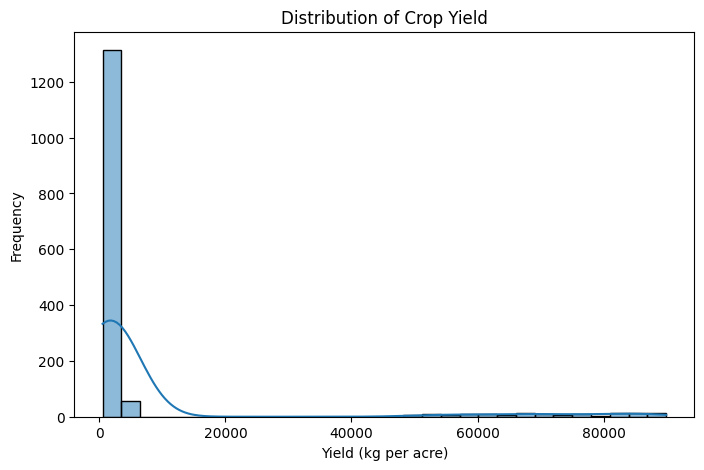

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Yield_kg_per_acre'], bins=30, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg per acre)")
plt.ylabel("Frequency")
plt.show()

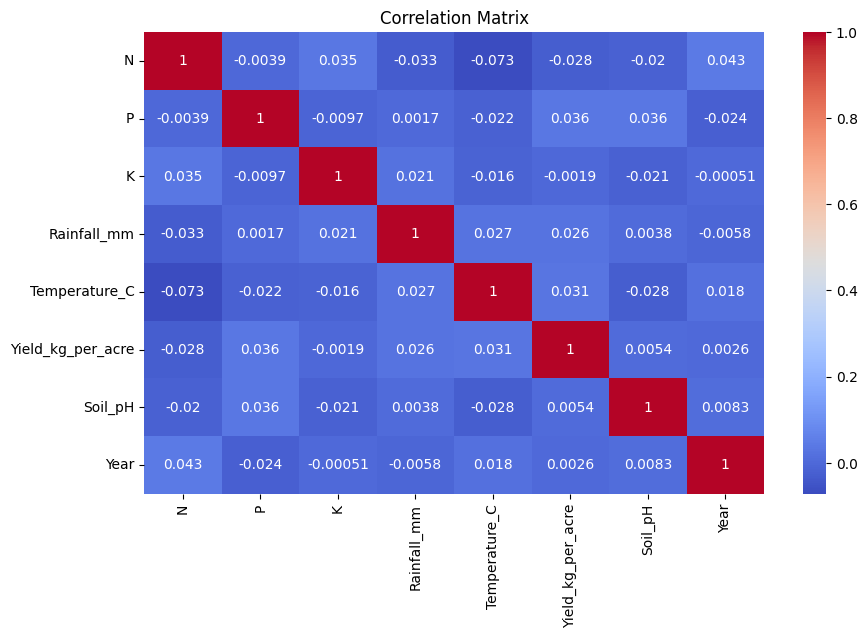

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [38]:
print("States:", df['State'].nunique())
print("Crops:", df['Crop'].nunique())
print("Soil Types:", df['Soil_Type'].nunique())
print("Fertilizers:", df['Fertilizer'].nunique())

States: 15
Crops: 10
Soil Types: 5
Fertilizers: 6


In [39]:
X = df.drop("Yield_kg_per_acre", axis=1)
y = df["Yield_kg_per_acre"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1500, 11)
Target shape: (1500,)


In [40]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Bihar,State_Gujarat,State_Haryana,...,Crop_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Potash,Fertilizer_Urea
0,96,41,51,123,31.06,6.82,2003,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,29,36,112,247,33.97,6.41,2002,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,37,38,177,142,24.21,7.06,2015,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,58,77,129,227,30.85,5.93,2022,False,True,False,...,True,False,False,True,False,False,False,False,False,False
4,108,61,63,263,37.81,6.24,2017,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [41]:
scaler = StandardScaler()

numerical_cols = ['N', 'P', 'K', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Year']

X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

X_encoded.head()

,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Bihar,State_Gujarat,State_Haryana,...,Crop_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Potash,Fertilizer_Urea
0,0.597758,-0.610072,-0.940526,-0.729557,0.503604,0.074040,-1.229915,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,-1.177342,-0.760465,0.181937,0.951763,1.006957,-0.491746,-1.365219,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,-0.965390,-0.700308,1.378005,-0.471936,-0.681264,0.405231,0.393735,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,-0.409015,0.472754,0.494755,0.680582,0.467280,-1.154129,1.340865,False,True,False,...,True,False,False,True,False,False,False,False,False,False
4,0.915687,-0.008502,-0.719714,1.168707,1.671175,-0.726340,0.664344,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [42]:
print("Final dataset shape after preprocessing:", X_encoded.shape)

Final dataset shape after preprocessing: (1500, 39)


MILESTONE 2

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

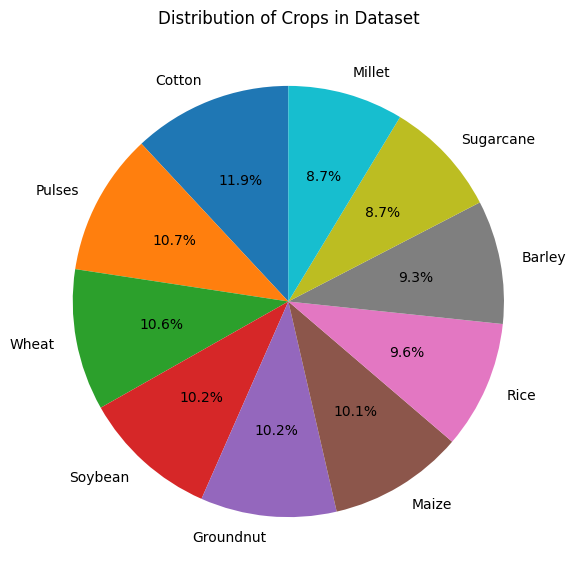

In [44]:
plt.figure(figsize=(7,7))

crop_counts = df['Crop'].value_counts()

plt.pie(crop_counts,
        labels=crop_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Crops in Dataset")
plt.show()

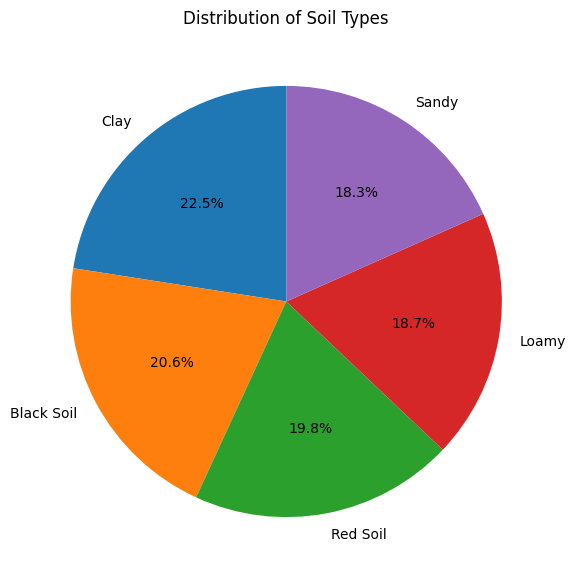

In [45]:
plt.figure(figsize=(7,7))

soil_counts = df['Soil_Type'].value_counts()

plt.pie(soil_counts,
        labels=soil_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Soil Types")
plt.show()

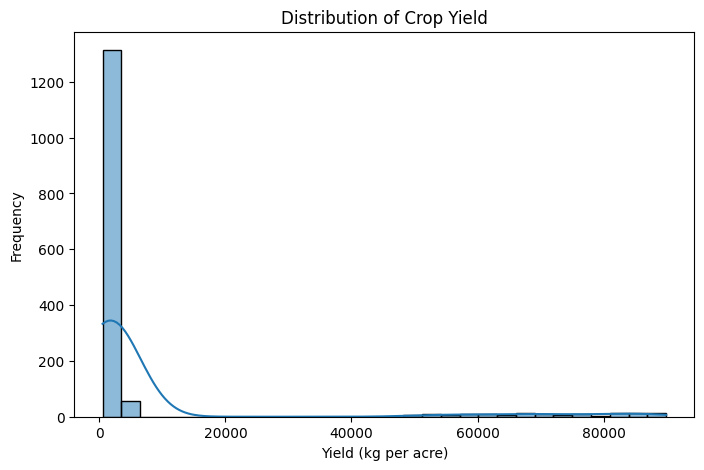

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(df['Yield_kg_per_acre'], bins=30, kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg per acre)")
plt.ylabel("Frequency")

plt.show()

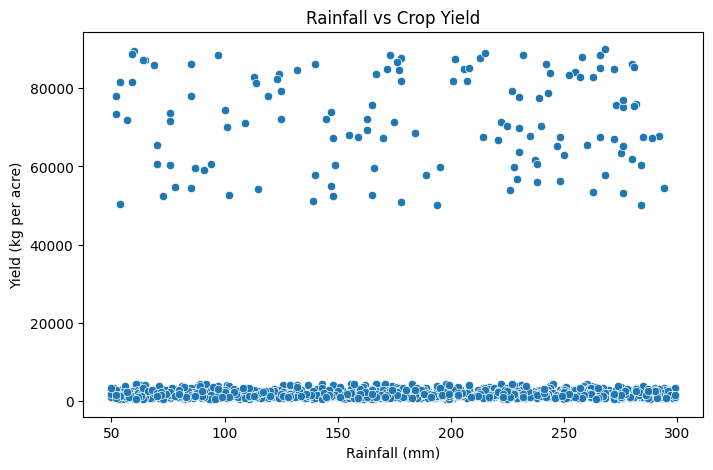

In [47]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Rainfall_mm'], y=df['Yield_kg_per_acre'])

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (kg per acre)")

plt.show()

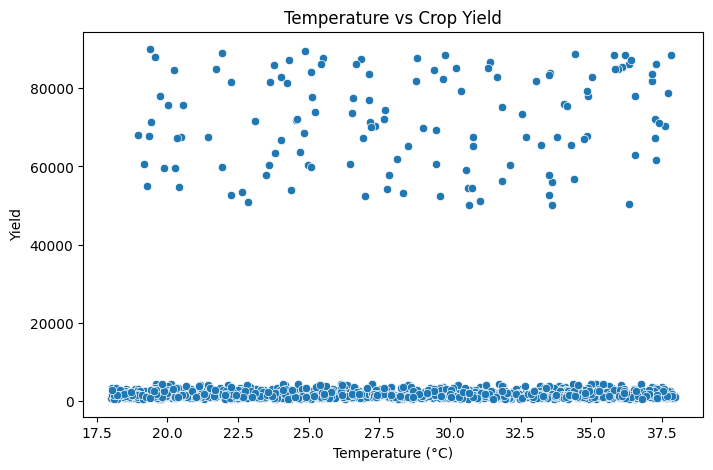

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Temperature_C'], y=df['Yield_kg_per_acre'])

plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield")

plt.show()

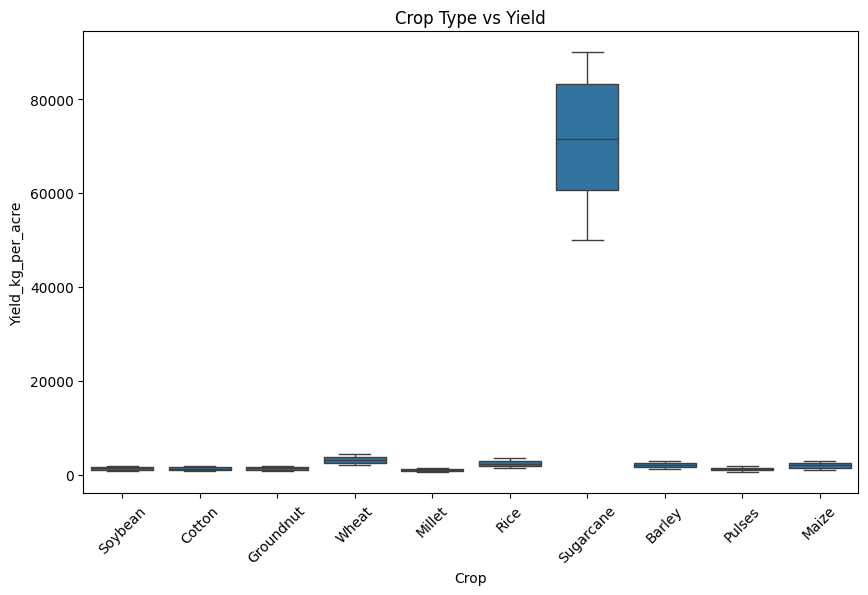

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['Crop'], y=df['Yield_kg_per_acre'])

plt.title("Crop Type vs Yield")
plt.xticks(rotation=45)

plt.show()

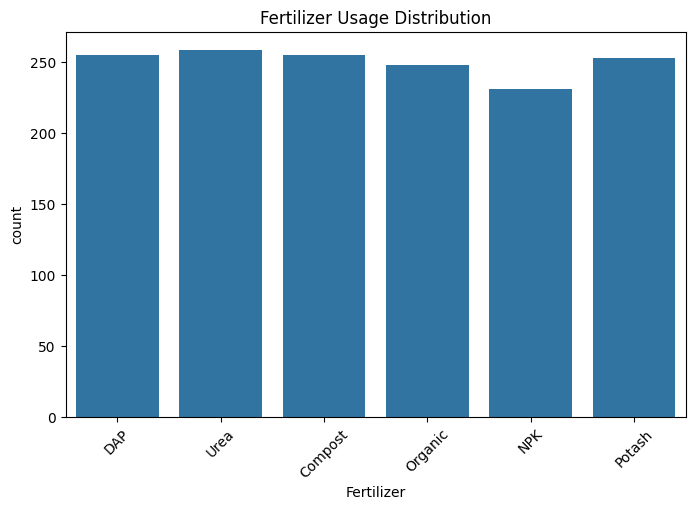

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['Fertilizer'])

plt.title("Fertilizer Usage Distribution")
plt.xticks(rotation=45)

plt.show()

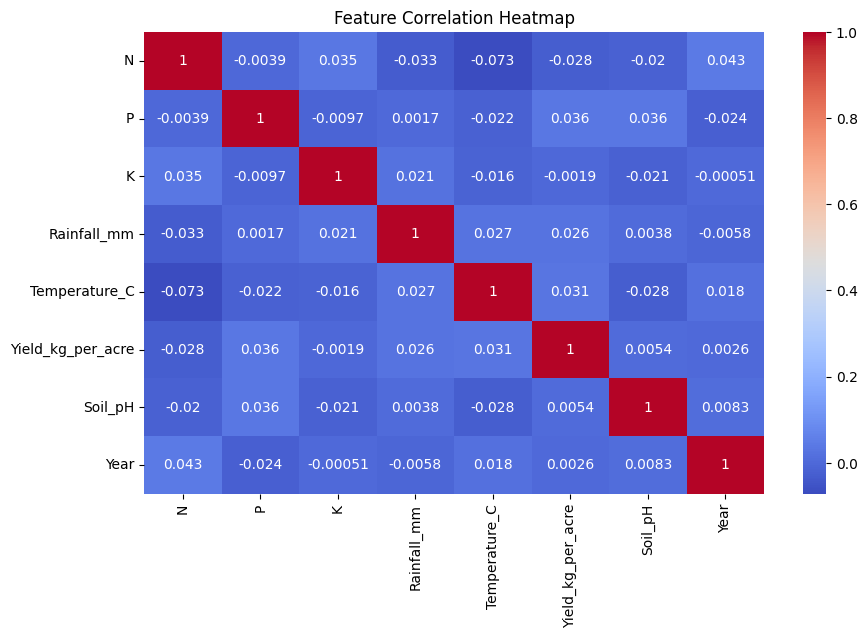

In [51]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
y = df['Yield_kg_per_acre']
X = df.drop('Yield_kg_per_acre', axis=1)

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['N','P','K','Rainfall_mm','Temperature_C','Soil_pH','Year']

X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

X_encoded.head()

,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Bihar,State_Gujarat,State_Haryana,...,Crop_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Potash,Fertilizer_Urea
0,0.597758,-0.610072,-0.940526,-0.729557,0.503604,0.074040,-1.229915,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,-1.177342,-0.760465,0.181937,0.951763,1.006957,-0.491746,-1.365219,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,-0.965390,-0.700308,1.378005,-0.471936,-0.681264,0.405231,0.393735,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,-0.409015,0.472754,0.494755,0.680582,0.467280,-1.154129,1.340865,False,True,False,...,True,False,False,True,False,False,False,False,False,False
4,0.915687,-0.008502,-0.719714,1.168707,1.671175,-0.726340,0.664344,False,False,False,...,False,True,False,False,False,False,False,True,False,False


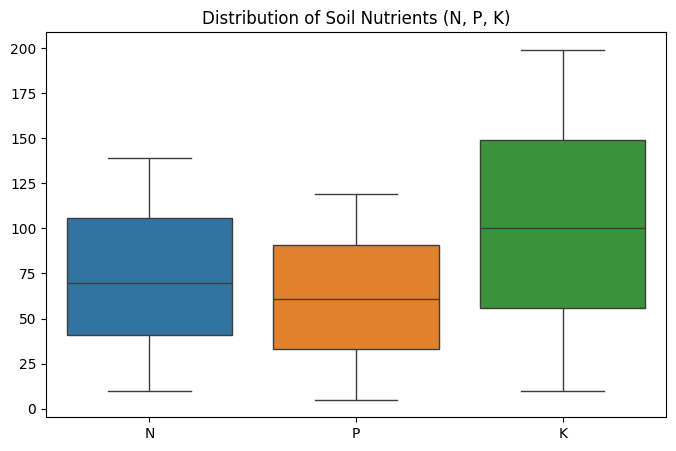

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['N','P','K']])
plt.title("Distribution of Soil Nutrients (N, P, K)")
plt.show()

In [54]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Bihar,State_Gujarat,State_Haryana,...,Crop_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Potash,Fertilizer_Urea
0,96,41,51,123,31.06,6.82,2003,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,29,36,112,247,33.97,6.41,2002,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,37,38,177,142,24.21,7.06,2015,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,58,77,129,227,30.85,5.93,2022,False,True,False,...,True,False,False,True,False,False,False,False,False,False
4,108,61,63,263,37.81,6.24,2017,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['N','P','K','Rainfall_mm','Temperature_C','Soil_pH','Year']

X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

In [61]:
print("Final dataset shape after preprocessing:", X_encoded.shape)

Final dataset shape after preprocessing: (1500, 39)
